In [109]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/borovai0/student-performance-analytics-dataset/student_performance_data.csv


*#  Student Performance Prediction (End-to-End ML Project)

##  Objective
The goal of this project is to analyze student data and build a machine learning model to predict final exam scores based on various factors like study hours, attendance, and extra classes.

---

##  Workflow
- Data Loading
- Data Exploration (EDA)
- Data Visualization
- Feature Engineering
- Data Preprocessing
- Model Building
- Model Evaluation

##  Data Loading

We begin by loading the dataset using pandas.

In [110]:
import pandas as pd 
data = pd.read_csv("/kaggle/input/datasets/borovai0/student-performance-analytics-dataset/student_performance_data.csv")

##  Data Understanding

- `head()` → View first few rows  
- `info()` → Check data types  
- `describe()` → Statistical summary  

In [111]:
data.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


In [112]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

In [113]:
data.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


##  Data Cleaning

We check for:
- Missing values
- Duplicate records

Result:
- No missing values
- No duplicate entries

In [114]:
data.isnull().sum()

student_id               0
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64

In [115]:
data.duplicated().sum()

np.int64(0)

##  Data Visualization

We explore patterns using:
- Count plots
- Histograms
- Scatter plots
- Box plots

<Axes: xlabel='gender', ylabel='count'>

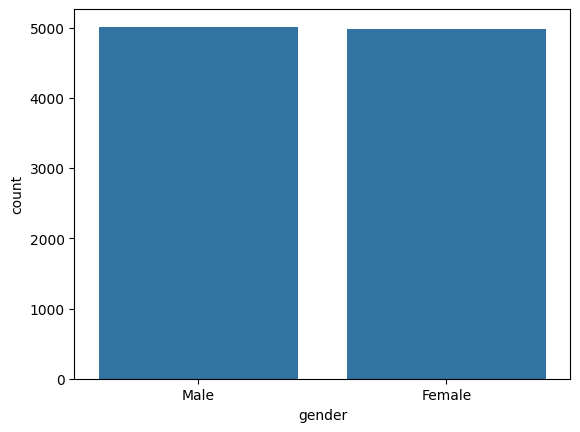

In [116]:
import seaborn as sns

sns.countplot(x='gender',data=data)


<Axes: xlabel='final_exam_score', ylabel='Count'>

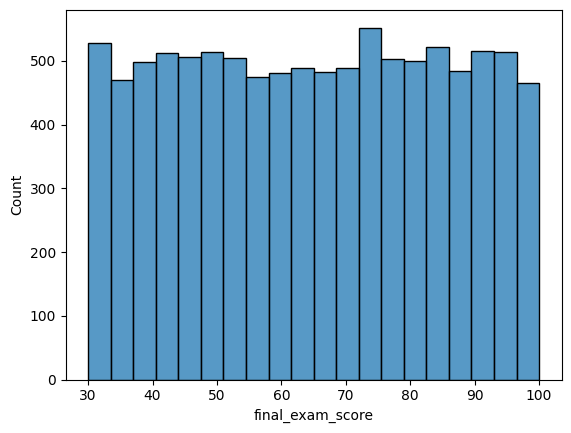

In [117]:
sns.histplot(data['final_exam_score'], bins=20)

<Axes: xlabel='study_hours_per_day', ylabel='Count'>

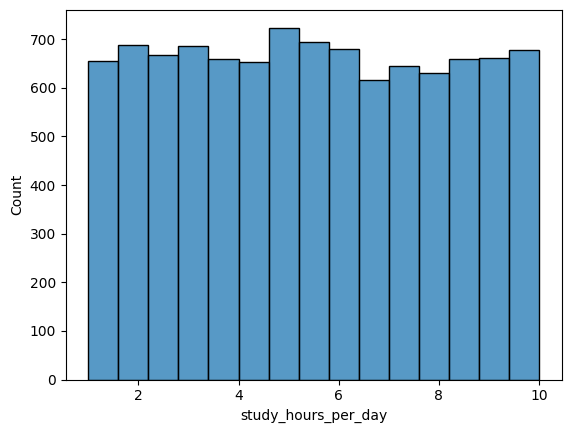

In [118]:
sns.histplot(data['study_hours_per_day'], bins=15)

<Axes: xlabel='study_hours_per_day', ylabel='final_exam_score'>

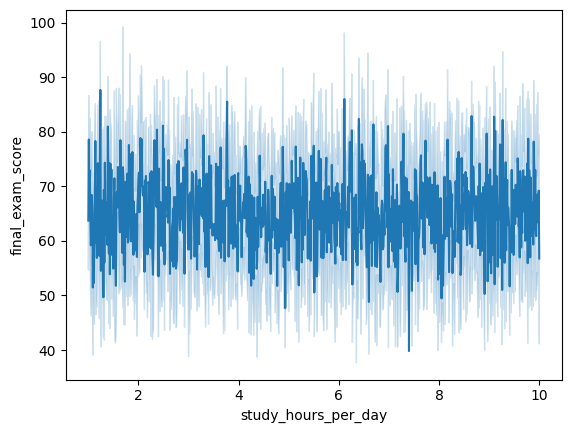

In [119]:
sns.lineplot(x = 'study_hours_per_day', y = 'final_exam_score',data=data)

<Axes: xlabel='attendance_percentage', ylabel='final_exam_score'>

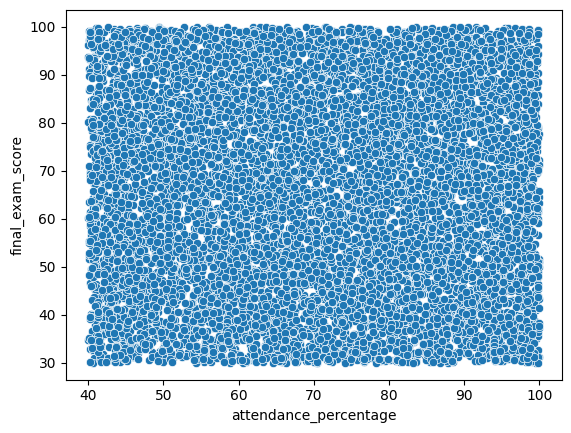

In [120]:
sns.scatterplot(x = 'attendance_percentage',y = 'final_exam_score',data=data)

<Axes: xlabel='gender', ylabel='final_exam_score'>

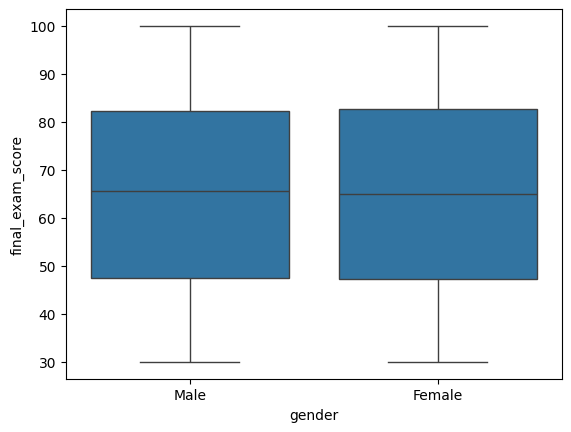

In [121]:
sns.boxplot(x = 'gender',y = 'final_exam_score',data=data)

<Axes: xlabel='extra_classes', ylabel='final_exam_score'>

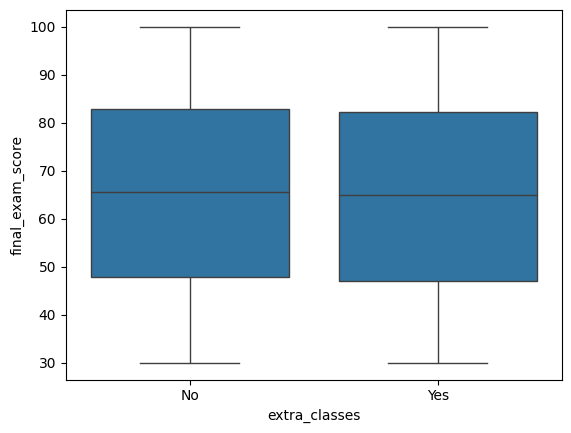

In [122]:
sns.boxplot(x = 'extra_classes', y = 'final_exam_score',data=data)

##  Correlation Heatmap

We analyze relationships between numerical variables using a heatmap.

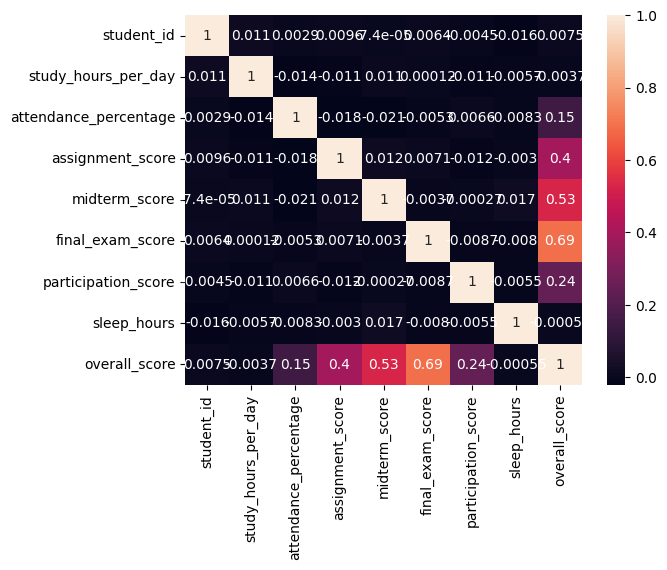

In [123]:
import matplotlib.pyplot as plt

sns.heatmap(data.select_dtypes(include='number').corr(), annot=True)
plt.show()

##  Feature Engineering

We create a new feature:

- **Study Efficiency** = Exam Score / Study Hours

This helps capture how effectively a student studies.

In [131]:
data['study_efficiency'] = data['final_exam_score']/(data['study_hours_per_day']+1)

##  Data Preprocessing

- Convert categorical variables using one-hot encoding
- Split data into training and testing sets
- Scale features for better model performance

In [125]:
data = pd.get_dummies(data, drop_first=True)

In [126]:
from sklearn.model_selection import train_test_split

X = data.drop('final_exam_score', axis=1)
y = data['final_exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##  Model Building

We use **Linear Regression** to predict student performance.

In [128]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [129]:
predictions = model.predict(X_test)


##  Model Evaluation

We evaluate using:
- Mean Squared Error (MSE)
- R² Score

These metrics help measure prediction accuracy.

In [130]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MSE: 1.1674510308546798e-27
R2 Score: 1.0


In [132]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, predictions))

MAE: 2.5984547846746864e-14


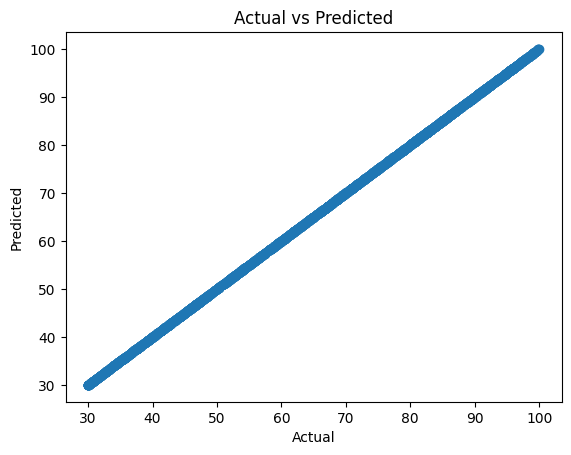

In [133]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

##  Conclusion

- Study hours and attendance significantly impact performance
- Feature engineering improved model understanding
- The model performs reasonably well in predicting exam scores

---

##  Future Improvements
- Try advanced models (Random Forest, XGBoost)
- Hyperparameter tuning
- More feature engineering